# L5 Data Cleaning & EDA

- Structure
  
  - File Formats (csv, tsv, json)

  - Variable Types

- Granularity & Temporality

- Faithfulness

  - Missing Values

<div style="background-color:#3b82f630; padding:12px 16px; border-left:5px solid #3b82f6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Definition:</strong> **Data Cleaning 数据清洗 / Data Wrangling 数据整理**

- The process of transforming raw data to facilitate subsequent analysis

	- May address issues like:
  
    	- Unclear structure & formatting

		- Missing & corrupted values
		
		- Unit conversions, etc.

- 简而言之就是做菜前要“备菜”

</div>

<div style="background-color:#3b82f630; padding:12px 16px; border-left:5px solid #3b82f6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Definition:</strong> **Exploratory Data Analysis (EDA) 数据探索**

- The process of understanding a new dataset

- 就是扫一眼数据长啥样，关于啥的，算算简单的平均数，方差啥的统计指标有个简单的初步理解，看看有没有什么有意思的特征或问题可以进一步探索

</div>

- Just some fancy words

## 1 Structure

- We usually prefer **rectangular data** for data analysis (i.e. A tablelike structure of data **with rows and cols**)

	- Easy to manipulate & analyze

- A key goal of data cleaning is to **make initial data more rectangular**

There are 2 types of rectangular data

- **Tables (表)**: have named columns with **different data types** and are manipulated using data transformation languages

- **Matrices (矩阵)**: contain **numeric data** of the **same type** and are manipulated using linear algebra

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

- Whether it contains different types of data is the key difference

- Matrices can be viewed as pure-number tables, which is a simple version of table

</div>

### File Formats

- There are many file types for storing structured data: TSV, JSON, XML, ASCII, SAS, etc

- We just introduce CSV, TSV, and JSON in lecture, you can learn others by yourself when encountering them

In [9]:
import pandas as pd
import numpy as np

**CSV (Comma-Separated Values)**

- Let's see the raw data before it is loaded into a df

- We can use `repr()` func to return raw string

In [1]:
with open("elections.csv", "r") as table:
    i = 0
    for row in table:
        print(repr(row))
        i += 1
        if i > 3:
            break

'Year,Candidate,Party,Popular vote,Result,%\n'
'1824,Andrew Jackson,Democratic-Republican,151271,loss,57.21012204\n'
'1824,John Quincy Adams,Democratic-Republican,113142,win,42.78987796\n'
'1828,Andrew Jackson,Democratic,642806,win,56.20392707\n'


- Each line is a **string**

- Each row (record) is delimited by a newline `\n`

- Each col (field) is delimited by a comma `,` (hence **comma-separated** values, csv)

In [10]:
pd.read_csv("elections.csv").head(5)

,Year,Candidate,Party,Popular vote,Result,%
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878
2,1828,Andrew Jackson,Democratic,642806,win,56.203927
3,1828,John Quincy Adams,National Republican,500897,loss,43.796073
4,1832,Andrew Jackson,Democratic,702735,win,54.574789


**TSV (Tab-Separated Values)**

- Same logic as for csv
  
- The record (row) is delimited by `\n`

- The field (col) is delimited by tab character `\t`

In [5]:
with open("elections.txt", "r") as table:
    i = 0
    for row in table:
        print(repr(row))
        i += 1
        if i > 3:
            break

'\ufeffYear\tCandidate\tParty\tPopular vote\tResult\t%\n'
'1824\tAndrew Jackson\tDemocratic-Republican\t151271\tloss\t57.21012204\n'
'1824\tJohn Quincy Adams\tDemocratic-Republican\t113142\twin\t42.78987796\n'
'1828\tAndrew Jackson\tDemocratic\t642806\twin\t56.20392707\n'


In [12]:
# We can also use the read_csv function to read tsv
# But we need to specify the delimiter as string '\t'
pd.read_csv("elections.txt", sep='\t').head(3)

,Year,Candidate,Party,Popular vote,Result,%
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878
2,1828,Andrew Jackson,Democratic,642806,win,56.203927


<div style="background-color:#8b5cf630; padding:12px 16px; border-left:5px solid #8b5cf6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Question:</strong> **How does `pandas` differentiate a delimiter `,` and a actual text `,` like in `8,900`?**

- It uses [quotechar parameter](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) to solve this

**quotechar: *str (length 1), optional***

Character used to denote the start and end of a quoted item.

Quoted items can include the delimiter and it will be ignored.

Only **one character** (length 1) is allowed

**e.g.**

`quotechar='"'`

- It means `"` is the sign of the start & end

```
"London, UK"
↑          ↑
start      end
```
</div>

**JSON (JavaScript Object Notation)**

- It is similar to a Python dictionary, generally a nested dict

In [13]:
with open("elections.json", "r") as table:
    i = 0
    for row in table:
        print(row)
        i += 1
        if i > 8:
            break

[

 {

   "Year": 1824,

   "Candidate": "Andrew Jackson",

   "Party": "Democratic-Republican",

   "Popular vote": 151271,

   "Result": "loss",

   "%": 57.21012204

 },



In [15]:
pd.read_json('elections.json').head(3)

,Year,Candidate,Party,Popular vote,Result,%
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878
2,1828,Andrew Jackson,Democratic,642806,win,56.203927


### *EDA with JSON (Demo)

- To get a JSON file containing information about the current members of Congress from California, you could use the following API call:

- https://api.congress.gov/v3/member/CA?api_key=[INSERT_KEY]&limit=250&format=json&currentMember=True

- You can instantly sign up for a congress.gov API key [here](https://gpo.congress.gov/sign-up/). Once you have your key, replace `[INSERT_KEY]` above with your key, and enter the API call as a URL in your browser to access the JSON file

- API keys are used to track how much a given user engages with the API
  
  - There might be limits to the number of API calls (e.g., congress.gov API limits to 5,000 calls per hour)
  
  - Or a cost for API calls (e.g., using the OpenAI API for programmatically using ChatGPT)

In [5]:
congress_file = "ca-congress-members.json"
print(type(congress_file))

# Inspect the first five lines of the file
with open(congress_file, "r") as f:
    for i, row in enumerate(f):
        print(row)
        if i >= 4: break

<class 'str'>
{

    "members": [

        {

            "bioguideId": "G000607",

            "depiction": {



In [2]:
import json

# Import the JSON file into Python as a dictionary
with open(congress_file, "rb") as f:
    congress_json = json.load(f)

type(congress_json)

dict

In [6]:
# Grab the list corresponding to the `members` key in the JSON dictionary, 
# and then grab the first element of this list.
# In a moment, we'll see how we knew to use the key `members`, and that
# the resulting object is a list.
congress_json['members'][0]

{'bioguideId': 'G000607',
 'depiction': {'imageUrl': 'https://www.congress.gov/img/member/6a29d4f81c6ce0de6fbae1f7_200.jpg'},
 'district': 1,
 'name': 'Gallagher, James',
 'partyName': 'Republican',
 'state': 'California',
 'terms': {'item': [{'chamber': 'House of Representatives',
    'startYear': 2026}]},
 'updateDate': '2026-08-09T07:40:25Z',
 'url': 'https://api.congress.gov/v3/member/G000607?format=json'}

- How should we probe a **nested dictionary** like congress_json?

- We can start by identifying the top-level keys of the dictionary

In [7]:
# Grab the top-level keys of the JSON dictionary
congress_json.keys()

dict_keys(['members', 'pagination', 'request'])

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **`meta` Key**

- You’ll often see a top-level meta key in JSON files
  
- It refers to metadata (data about the data). Metadata are often maintained alongside the data

</div>

In [8]:
type(congress_json['members'])

list

In [9]:
congress_json['members'][:2]

[{'bioguideId': 'G000607',
  'depiction': {'imageUrl': 'https://www.congress.gov/img/member/6a29d4f81c6ce0de6fbae1f7_200.jpg'},
  'district': 1,
  'name': 'Gallagher, James',
  'partyName': 'Republican',
  'state': 'California',
  'terms': {'item': [{'chamber': 'House of Representatives',
     'startYear': 2026}]},
  'updateDate': '2026-08-09T07:40:25Z',
  'url': 'https://api.congress.gov/v3/member/G000607?format=json'},
 {'bioguideId': 'F000483',
  'depiction': {'attribution': 'Image courtesy of the Member',
   'imageUrl': 'https://www.congress.gov/img/member/6a0f0dcb69b12040cf77e337_200.jpg'},
  'district': 30,
  'name': 'Friedman, Laura',
  'partyName': 'Democratic',
  'state': 'California',
  'terms': {'item': [{'chamber': 'House of Representatives',
     'startYear': 2025}]},
  'updateDate': '2026-08-09T07:40:25Z',
  'url': 'https://api.congress.gov/v3/member/F000483?format=json'}]

In [10]:
print(congress_json['pagination'])
print(congress_json['request'])

{'count': 53}
{'contentType': 'application/json', 'format': 'json'}


- The two other elements of `congress_json` don’t have the same structure as `congress_json['members']`

- Hence they cannot belong in a df containing `members` (Since inconsistancy prevents convertion)

<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> **pd.read_json(json_file) may not work**

- The json can be not consistant in the formats

**e.g.**

- Say a JSON file looks like this:

```
{
    "pagination": {
        "count": 250,
        "next": "..."
    },

    "request": {
        "format": "json"
    },

    "members": [
        {"name": "A", "state": "CA"},
        {"name": "B", "state": "NY"},
        {"name": "C", "state": "TX"}
    ]
}
```

- Pandas can parse it successfully but don't know how to transform this unshaped data into one rectangular table

</div>

In [12]:
# This line intentionally produces an error
import pandas as pd
pd.read_json(congress_file)

ValueError: Mixing dicts with non-Series may lead to ambiguous ordering.

- But it is doable to extract one element which is aligned with the df format

In [13]:
# Convert dictionary to DataFrame
congress_df = pd.DataFrame(congress_json['members'])
congress_df.head()

,bioguideId,depiction,district,name,partyName,state,terms,updateDate,url
0,G000607,{'imageUrl': 'https://www.congress.gov/img/mem...,1.0,"Gallagher, James",Republican,California,{'item': [{'chamber': 'House of Representative...,2026-08-09T07:40:25Z,https://api.congress.gov/v3/member/G000607?for...
1,F000483,{'attribution': 'Image courtesy of the Member'...,30.0,"Friedman, Laura",Democratic,California,{'item': [{'chamber': 'House of Representative...,2026-08-09T07:40:25Z,https://api.congress.gov/v3/member/F000483?for...
2,F000480,{'attribution': 'Image courtesy of the Member'...,20.0,"Fong, Vince",Republican,California,{'item': [{'chamber': 'House of Representative...,2026-08-09T07:40:25Z,https://api.congress.gov/v3/member/F000480?for...
3,C001123,{'attribution': 'Image courtesy of the Member'...,31.0,"Cisneros, Gilbert Ray",Democratic,California,{'item': [{'chamber': 'House of Representative...,2026-08-09T07:40:25Z,https://api.congress.gov/v3/member/C001123?for...
4,M001225,{'attribution': 'Image courtesy of the Member'...,15.0,"Mullin, Kevin",Democratic,California,{'item': [{'chamber': 'House of Representative...,2026-08-09T07:40:24Z,https://api.congress.gov/v3/member/M001225?for...


### Other Data Formats

- Some other data may not seem tabular, but they actually can be transformed into matrix form

	- **Image** Data: Used for medical diagnosis

	- **Audio** Data: Used for speech recognition, sentiment analysis

	- **Video** Data: Used for object tracking, facial recognition

	- **Text**: Used for LLMs, document review

### Variable Types

- Variables are **columns**

- A var is a measurement of a particular concept **with 2 properties:**

	- **Data type / Storage type**: int? float? boolean? str? etc.
    	
		- It affects which funcs can be used

	- **Variable type / Feature type**: Conceptualized measurement of information, the meaning in the reality, the statistical meaning

		- It affects how to interpret and what operations need to perform

- Generally we can categorize vars into 2 overarching types:

	- **Quantitative** variables

	- **Qualitative** variables / **Categorical** variables
  	
    	- **Ordinal** qualitative variables
    	
		- **Nominal** qualitative variables

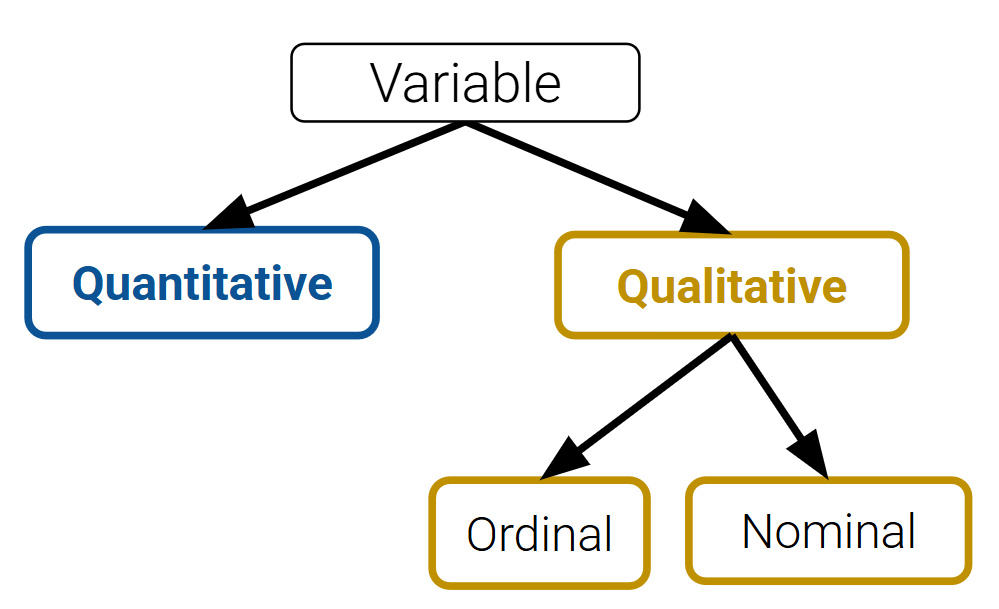

## 2 Granularity & Temporality

### Granularity (粒度)

- The granularity of a dataset is **what a single row represents**

- It reflects the **level of detail** included in the data

### Temporality（时间性）

- The temporality of a dataset describes the **periodicity** over which the data was collected as well as **when the data was most recently collected or updated**

- Time and date fields of a dataset could represent:

	- When the "event" happened?
	
	- When the data was collected and entered into system?
	
	- When the data was copied into database?

- To better undeerstand temporality, we need to **standardize the time zone and time format**

- The convention for standardized time is the **Coordinated Universal Time (UTC)**, an international time standard measured at 0 degrees latitude that stays consistent throughout the year (no daylight savings)

**`pandas' dt` Accessors (DateTime)**

In [16]:
calls = pd.read_csv("Berkeley_PD_-_Calls_for_Service.csv")
calls.head()

,CASENO,OFFENSE,EVENTDT,EVENTTM,CVLEGEND,CVDOW,InDbDate,Block_Location,BLKADDR,City,State
0,21014296,THEFT MISD. (UNDER $950),04/01/2021 12:00:00 AM,10:58,LARCENY,4,06/15/2021 12:00:00 AM,"Berkeley, CA\n(37.869058, -122.270455)",NaN,Berkeley,CA
1,21014391,THEFT MISD. (UNDER $950),04/01/2021 12:00:00 AM,10:38,LARCENY,4,06/15/2021 12:00:00 AM,"Berkeley, CA\n(37.869058, -122.270455)",NaN,Berkeley,CA
2,21090494,THEFT MISD. (UNDER $950),04/19/2021 12:00:00 AM,12:15,LARCENY,1,06/15/2021 12:00:00 AM,"2100 BLOCK HASTE ST\nBerkeley, CA\n(37.864908,...",2100 BLOCK HASTE ST,Berkeley,CA
3,21090204,THEFT FELONY (OVER $950),02/13/2021 12:00:00 AM,17:00,LARCENY,6,06/15/2021 12:00:00 AM,"2600 BLOCK WARRING ST\nBerkeley, CA\n(37.86393...",2600 BLOCK WARRING ST,Berkeley,CA
4,21090179,BURGLARY AUTO,02/08/2021 12:00:00 AM,6:20,BURGLARY - VEHICLE,1,06/15/2021 12:00:00 AM,"2700 BLOCK GARBER ST\nBerkeley, CA\n(37.86066,...",2700 BLOCK GARBER ST,Berkeley,CA


- `EVENTDT` stands for the date when the event took place

- `EVENTTM` stands for the time of day the event took place (in 24-hr format)

- `InDbDate` is the date this call is recorded onto the database

- **They are stored as strings here**, need transforming into `datetime`

In [17]:
calls["EVENTDT"] = pd.to_datetime(calls["EVENTDT"])
calls.head()

/var/folders/2t/f3t7qgfn0b52xhlj1dvj417c0000gn/T/ipykernel_46813/874729699.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  calls["EVENTDT"] = pd.to_datetime(calls["EVENTDT"])


,CASENO,OFFENSE,EVENTDT,EVENTTM,CVLEGEND,CVDOW,InDbDate,Block_Location,BLKADDR,City,State
0,21014296,THEFT MISD. (UNDER $950),2021-04-01,10:58,LARCENY,4,06/15/2021 12:00:00 AM,"Berkeley, CA\n(37.869058, -122.270455)",NaN,Berkeley,CA
1,21014391,THEFT MISD. (UNDER $950),2021-04-01,10:38,LARCENY,4,06/15/2021 12:00:00 AM,"Berkeley, CA\n(37.869058, -122.270455)",NaN,Berkeley,CA
2,21090494,THEFT MISD. (UNDER $950),2021-04-19,12:15,LARCENY,1,06/15/2021 12:00:00 AM,"2100 BLOCK HASTE ST\nBerkeley, CA\n(37.864908,...",2100 BLOCK HASTE ST,Berkeley,CA
3,21090204,THEFT FELONY (OVER $950),2021-02-13,17:00,LARCENY,6,06/15/2021 12:00:00 AM,"2600 BLOCK WARRING ST\nBerkeley, CA\n(37.86393...",2600 BLOCK WARRING ST,Berkeley,CA
4,21090179,BURGLARY AUTO,2021-02-08,6:20,BURGLARY - VEHICLE,1,06/15/2021 12:00:00 AM,"2700 BLOCK GARBER ST\nBerkeley, CA\n(37.86066,...",2700 BLOCK GARBER ST,Berkeley,CA


- We can use `dt` to get months

In [18]:
calls["EVENTDT"].dt.month.head()

0    4
1    4
2    4
3    2
4    2
Name: EVENTDT, dtype: int32

- Also which day of the week the date is on (周几)

In [19]:
calls["EVENTDT"].dt.dayofweek.head()

0    3
1    3
2    0
3    5
4    0
Name: EVENTDT, dtype: int32

- We can also use `dt` to switch time zones, convert time back to UNIX/POSIX time etc.

- More func can see the documentation on [`.dt` accessor](https://pandas.pydata.org/docs/user_guide/basics.html#basics-dt-accessors) & [time series/date functionality](https://pandas.pydata.org/docs/user_guide/timeseries.html#)

<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **UNIX/POSIX Time**

- Can be thought as "From a pre-determined time, how many seconds have gone so far?"

- The starting time is **Unix Epoch (Unix 纪元)**: 1970-01-01 00:00:00 UTC

```
1970-01-01 00:00:00 UTC → Unix time = 0
1970-01-01 00:00:01 UTC → Unix time = 1
1970-01-01 00:01:00 UTC → Unix time = 60
1970-01-02 00:00:00 UTC → Unix time = 86400
```

- We call the `int` like 86400 a **Unix Timestamp (Unix 时间戳)**

- Compared to common time format, this way **doesn't need to worry about time zone** since everywhere at the same moment shares the same Unix timestamp
</div>

## 3 Faithfulness

- To make models work, we need to make sure the data we use is faithful to reality (i.e. our data **accurately captures the “real world”**)

Some common issues:

- **Unrealistic or “incorrect” values**
  - such as negative counts, locations that don’t exist, or dates set in the future

- **Violations of obvious dependencies**
  - like an age that does not match a birthday

- **Clear signs that data was entered by hand**
  - which can lead to spelling errors or fields that are incorrectly shifted

- **Signs of data falsification**
  - such as fake email addresses or repeated use of the same names

- **Duplicated records or fields**
  - containing the same information

- **Truncated data**
  - e.g. Microsoft Excel would limit the number of rows to 655536 and the number of columns to 255



Some solutions:

- **Spelling errors**: apply *corrections* or *drop* records that aren’t in a dictionary

- **Time zone inconsistencies**: *convert to a common time zone* (e.g. UTC)

- **Duplicated records or fields**: identify and *eliminate duplicates (using primary keys)*

- **Unspecified or inconsistent units**: infer the units and check that values are in reasonable ranges in the data

### Missing Values

**Solutions**

- Drop the records
  
  - But can introduce the risk of inducting bias (i.e. the corrupt records are systematically related to some features of interest of the data)

- Keep the data as `NaN`

- Imputation

  - Infer the missing values
  
    - Average
    
	- Hot deck
    	
		- One missing value → one imputed observed value → one completed dataset
	
	- Regression
	
	- Multiple
  	
    	- One missing value → multiple plausible values → multiple completed datasets → combine the analyses

## Demo 1: Flu in the US

### CSVs and Field Names

In [ ]:
with open("flu/ILINet.csv", "r") as f:
    i = 0
    for row in f:
        print(row) # This will generate a /n at the end
        i += 1
        if i > 3:
            break

PERCENTAGE OF VISITS FOR INFLUENZA-LIKE-ILLNESS REPORTED BY SENTINEL PROVIDERS

REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS

HHS Regions,Region 1,2015,40,0.743302,0.684364,103,50,,133,23,13,322,134,47051

HHS Regions,Region 2,2015,40,1.03278,1.22475,547,294,,528,123,95,1587,199,129577



- There are blank lines interspaced between the lines

- Since Python’s `print()` prints each string (including the newline), and **adds an additional newline on top of that**

In [22]:
with open("flu/ILINet.csv", "r") as f:
    i = 0
    for row in f:
        print(repr(row)) # print raw strings
        i += 1
        if i > 3:
            break

'PERCENTAGE OF VISITS FOR INFLUENZA-LIKE-ILLNESS REPORTED BY SENTINEL PROVIDERS\n'
'REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS\n'
'HHS Regions,Region 1,2015,40,0.743302,0.684364,103,50,,133,23,13,322,134,47051\n'
'HHS Regions,Region 2,2015,40,1.03278,1.22475,547,294,,528,123,95,1587,199,129577\n'


- No new lines now

- Try importing it into df

In [25]:
ili = pd.read_csv("flu/ILINet.csv")
ili

PERCENTAGE OF VISITS FOR INFLUENZA-LIKE-ILLNESS REPORTED BY SENTINEL PROVIDERS
REGION TYPE REGION    YEAR WEEK % WEIGHTED ILI %UNWEIGHTED ILI AGE 0-4 AGE 25-49 AGE 25-64 AGE 5-24 AGE 50-64 AGE 65 ILITOTAL NUM. OF PROVIDERS                                     TOTAL PATIENTS                            
HHS Regions Region 1  2015 40   0.743302       0.684364        103     50        NaN       133      23        13     322      134                                                            47051                            
            Region 2  2015 40   1.03278        1.22475         547     294       NaN       528      123       95     1587     199                                                           129577                            
            Region 3  2015 40   1.2178         1.24313         401     419       NaN       625      144       81     1670     280                                                           134338                            
            Region 4  2015 40   1.01464        1.15781         486     231       NaN       613      99        75     1504     299                                                           129900                            
...                                                                                                                                                                                            ...                            
            Region 6  2026 3    6.71907        6.40685         1189    1313      NaN       2393     451       375    5721     205                                                            89295                            
            Region 7  2026 3    5.70345        5.79518         518     722       NaN       1174     228       338    2980     164                                                            51422                            
            Region 8  2026 3    3.03915        3.08624         684     670       NaN       1000     246       289    2889     228                                                            93609                            
            Region 9  2026 3    4.85718        4.62364         2045    5863      NaN       4914     2552      3004   18378    402                                                           397479                            
            Region 10 2026 3    5.06699        4.91184         1462    1946      NaN       3526     700       793    8427     332                                                           171565                            

[5381 rows x 1 columns]

- Only one col with a weird label

- The first row is also weird

- We need to wrangle it a bit

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong>

- `pd.read_csv` sets the first row as the header Conventionally

- i.e. `header=0`

</div>

In [27]:
ili = pd.read_csv("flu/ILINet.csv", header=1) # row index
ili.head(5)

,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS
0,HHS Regions,Region 1,2015,40,0.743302,0.684364,103,50,NaN,133,23,13,322,134,47051
1,HHS Regions,Region 2,2015,40,1.032780,1.224750,547,294,NaN,528,123,95,1587,199,129577
2,HHS Regions,Region 3,2015,40,1.217800,1.243130,401,419,NaN,625,144,81,1670,280,134338
3,HHS Regions,Region 4,2015,40,1.014640,1.157810,486,231,NaN,613,99,75,1504,299,129900
4,HHS Regions,Region 5,2015,40,1.042590,1.177230,384,238,NaN,444,159,103,1328,284,112807


### Granularity of the records

- We have imported the data, now we can inspect it

- We can see each entry represent a **unique combination** of **week, year, region**

### Visualization

**Preprocessing and column manipulation**

- It records observations over a period of time and is separated by region

- We want to display trends over time

- But `YEAR` and `WEEK` are in 2 separate cols, we need to combine them first for a single x-axis 

In [29]:
# Ideas see below
ili['week_start'] = pd.to_datetime(
    (ili['YEAR'] * 100 + ili['WEEK']).astype(str) + '0', 
    format='%Y%W%w'
)
ili.sample(3) # randomly pick (sample) 3 rows

,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,week_start
1497,HHS Regions,Region 8,2018,33,0.255081,0.331233,67,51,NaN,109,23,17,267,134,80608,2018-08-19
4907,HHS Regions,Region 8,2025,9,3.802160,3.812090,1060,941,NaN,1295,403,416,4115,240,107946,2025-03-09
4910,HHS Regions,Region 1,2025,10,4.443070,4.464340,810,2040,NaN,2202,1005,1421,7478,283,167505,2025-03-16


<div style="background-color:#9ca3af30; padding:12px 16px; border-left:5px solid #9ca3af; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Note:</strong> **Why code like this?**

**e.g.**

say: YEAR = 2024, WEEK = 15

`ili['YEAR'] * 100 + ili['WEEK']`

yields 2024 * 100 + 15 = **202415**

`.astype(str) + '0'`

it adds a `0` at the end and turns it into str: `'2024150'`

`format='%Y%W%w'`

| **格式** | **含义** | **例子** |
| --- | --- | --- |
| `%Y` | 四位年份 | `2024` |
| `%W` | 一年中的第几周，**周一作为一周开始** | `15` |
| `%w` | 星期几：`0=Sunday`, `1=Monday`, … | `0` |

```
2024150
│   │ │
│   │ └─ Sunday
│   └─── week 15
└─────── year 2024
```
</div>

- Now we can access datetime using `dt`

	- `dt.year`
	
	- `dt.month`
	

In [40]:
ili['week_start'].dt.year.head()

0    2015
1    2015
2    2015
3    2015
4    2015
Name: week_start, dtype: int32

In [31]:
ili['week_start'].dtype

dtype('<M8[ns]')

- `ns` above stands for nanoseconds

- `<M8` refers to the Numpy type `datetime64`

- Under the hood, datetimes are **intergers** representing the number of nanoseconds since 1/1/1970 UTC (i.e. a special kind of Unix timestamp)

### Plotting

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

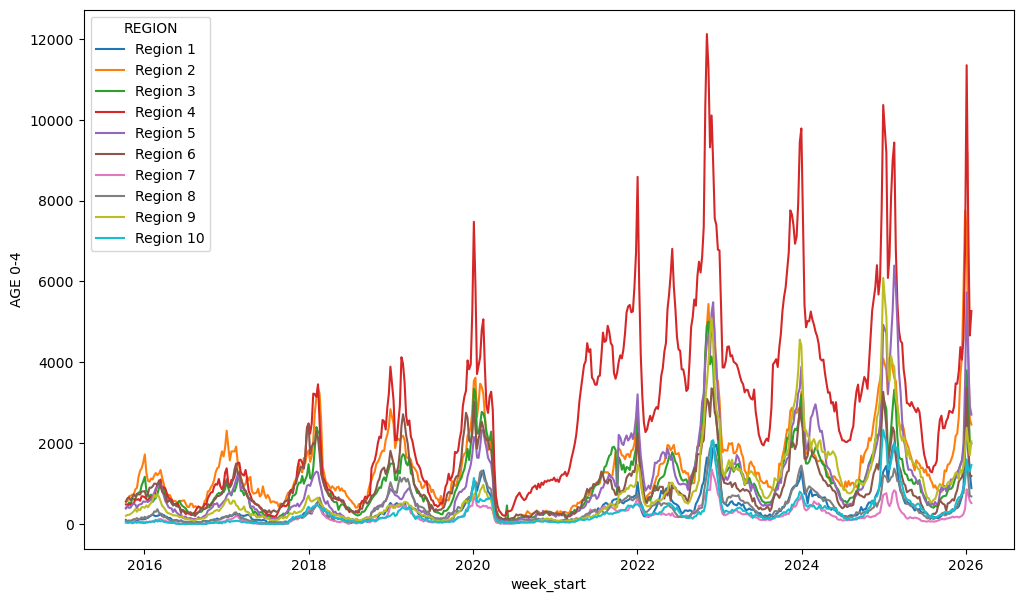

In [ ]:
# Visualize number of cases for babies and small children
# hue here is used to separate the data by REGION, not much about colors
f, ax = plt.subplots(1, 1, figsize=(12, 7))
sns.lineplot(ili, x='week_start', y='AGE 0-4', hue='REGION', ax=ax);

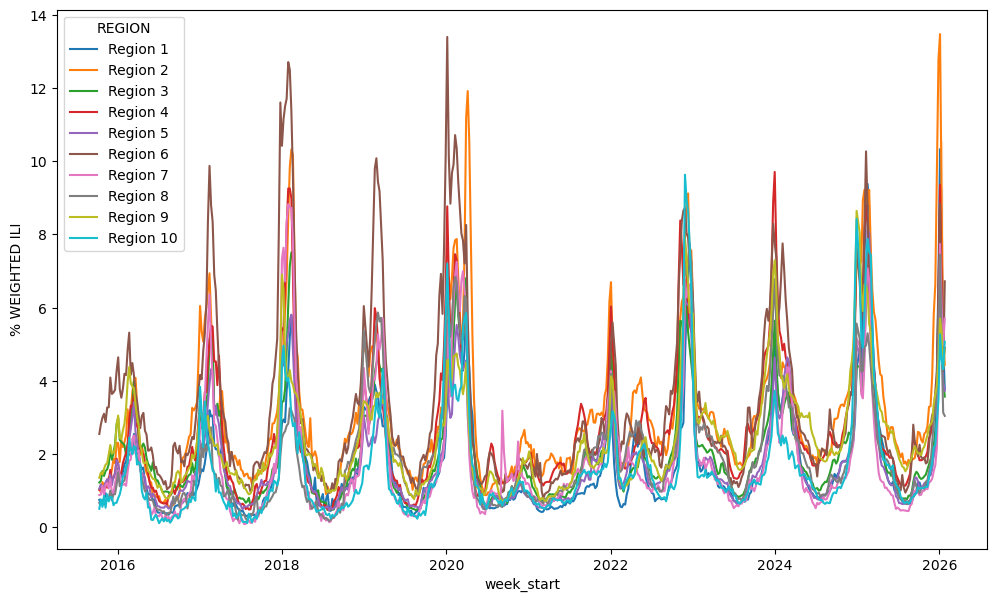

In [41]:
# Visualize overall prevalence of flu
f, ax = plt.subplots(1, 1, figsize=(12, 7))
sns.lineplot(ili, x='week_start', y='% WEIGHTED ILI', hue='REGION', ax=ax);

### Load vaccination data

In [42]:
vax = pd.read_csv('flu/monthly_child_flu_vaccination.csv')
vax['month_dt'] = pd.to_datetime(vax['month_dt'])
vax['rate'] = vax['Numerator'] / vax['Population']
vax.head(14)

,HHS Region,month_dt,Numerator,Population,rate
0,Region 1,2022-07-01,17110.0,1328581.0,0.012878
1,Region 1,2022-08-01,42110.0,1328581.0,0.031695
2,Region 1,2022-09-01,129698.0,1328581.0,0.097621
3,Region 1,2022-10-01,297855.0,1328581.0,0.224190
4,Region 1,2022-11-01,430376.0,1328581.0,0.323937
5,Region 1,2022-12-01,508781.0,1328581.0,0.382951
6,Region 1,2023-01-01,545783.0,1328581.0,0.410801
7,Region 1,2023-02-01,563456.0,1328581.0,0.424104
8,Region 1,2023-03-01,575885.0,1328581.0,0.433459
9,Region 1,2023-04-01,581451.0,1328581.0,0.437648


### Joining Data (Merging different `DataFrame`)

In [ ]:
# If one df, it will call display() automatically
# But if we want to see multiple dfs, we need to call display() explicitly
display(ili.tail(2))
display(vax.tail(2))

,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,AGE 50-64,AGE 65,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,week_start
5378,HHS Regions,Region 9,2026,3,4.85718,4.62364,2045,5863,NaN,4914,2552,3004,18378,402,397479,2026-01-25
5379,HHS Regions,Region 10,2026,3,5.06699,4.91184,1462,1946,NaN,3526,700,793,8427,332,171565,2026-01-25


,HHS Region,month_dt,Numerator,Population,rate
418,Region 9,2025-11-01,1416002.0,8216613.0,0.172334
419,Region 9,2025-12-01,1686327.0,8216613.0,0.205234


- We need to join them by **time**

- So we need to transform the week in a year into the month

	- We choose to associate each week with the month in which its start date falls. This isn’t the only way we could do this, and it also isn’t perfect: there may be weeks that are split across two months where the numbers won’t match up exactly

In [44]:
ili["month"] = ili["week_start"].dt.to_period("M").dt.to_timestamp()

In [ ]:
ili_vax = ili.merge(
    vax, 
    left_on=['month', 'REGION'], # Composite key consisting of two columns
    right_on=['month_dt', 'HHS Region'] # Both conditions must match for two rows to be merged
)
ili_vax.head()

,REGION TYPE,REGION,YEAR,WEEK,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 25-49,AGE 25-64,AGE 5-24,...,ILITOTAL,NUM. OF PROVIDERS,TOTAL PATIENTS,week_start,month,HHS Region,month_dt,Numerator,Population,rate
0,HHS Regions,Region 1,2022,26,0.930656,1.02061,440,356,NaN,346,...,1519,232,148833,2022-07-03,2022-07-01,Region 1,2022-07-01,17110.0,1328581.0,0.012878
1,HHS Regions,Region 2,2022,26,2.801480,2.49609,1756,630,NaN,1124,...,4085,161,163656,2022-07-03,2022-07-01,Region 2,2022-07-01,699.0,1982009.0,0.000353
2,HHS Regions,Region 3,2022,26,1.388480,1.62687,1347,883,NaN,929,...,3916,371,240707,2022-07-03,2022-07-01,Region 3,2022-07-01,284.0,4301556.0,0.000066
3,HHS Regions,Region 4,2022,26,2.290100,2.47071,4320,3555,NaN,3430,...,14144,928,572466,2022-07-03,2022-07-01,Region 4,2022-07-01,2268.0,13203279.0,0.000172
4,HHS Regions,Region 5,2022,26,1.150380,1.05771,1001,678,NaN,817,...,3176,610,300270,2022-07-03,2022-07-01,Region 5,2022-07-01,662.0,11492529.0,0.000058


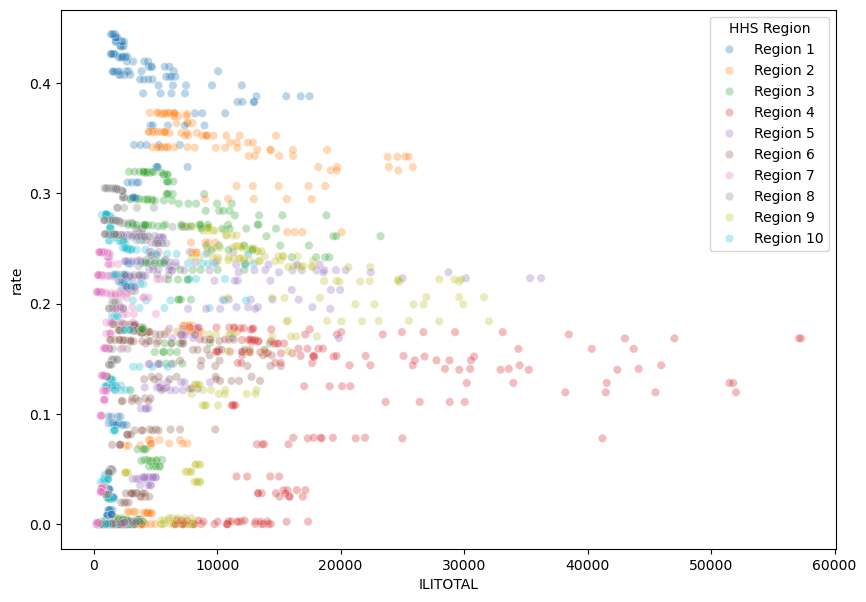

In [46]:
f, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.scatterplot(ili_vax, x='ILITOTAL', y='rate', alpha=0.3, hue='HHS Region', ax=ax);

## Demo 2: Mauna Loa CO2 Data – A Lesson in Data Faithfulness

In [60]:
import pandas as pd
import numpy as np
co2_file = "co2_mm_mlo.txt"

### Reading this file into Pandas? Check First!

```
line number |                            file contents

71          |   #            decimal     average   interpolated    trend    #days
72          |   #             date                             (season corr)
73          |   1958   3    1958.208      315.71      315.71      314.62     -1
74          |   1958   4    1958.292      317.45      317.45      315.29     -1
75          |   1958   5    1958.375      317.50      317.50      314.71     -1
76          |   1958   6    1958.458      -99.99      317.10      314.85     -1
77          |   1958   7    1958.542      315.86      315.86      314.98     -1
78          |   1958   8    1958.625      314.93      314.93      315.94     -1
```

- The value are seperated by white space, possibly tabs

- The data line up down the rows (e.g. the month appears in 7th to 8th position of each line)

- The 71st and 72nd lines in the file **contain column headings split over two lines**

- We can specify the arguments of `read_csv` to adapt to it

In [48]:
co2 = pd.read_csv(
    co2_file, header = None, skiprows = 72,
    sep = r'\s+'       #delimiter for continuous whitespace (stay tuned for regex next lecture))
)
co2.head()

,0,1,2,3,4,5,6
0,1958,3,1958.208,315.71,315.71,314.62,-1
1,1958,4,1958.292,317.45,317.45,315.29,-1
2,1958,5,1958.375,317.50,317.50,314.71,-1
3,1958,6,1958.458,-99.99,317.10,314.85,-1
4,1958,7,1958.542,315.86,315.86,314.98,-1


- The columns are not named

In [ ]:
co2 = pd.read_csv(
    co2_file, header = None, skiprows = 72,
    sep = r'\s+', #regex for continuous whitespace (next lecture)
    names = ['Yr', 'Mo', 'DecDate', 'Avg', 'Int', 'Trend', 'Days'] # Set the names
)
co2.head()

,Yr,Mo,DecDate,Avg,Int,Trend,Days
0,1958,3,1958.208,315.71,315.71,314.62,-1
1,1958,4,1958.292,317.45,317.45,315.29,-1
2,1958,5,1958.375,317.50,317.50,314.71,-1
3,1958,6,1958.458,-99.99,317.10,314.85,-1
4,1958,7,1958.542,315.86,315.86,314.98,-1


### Visualizing CO2

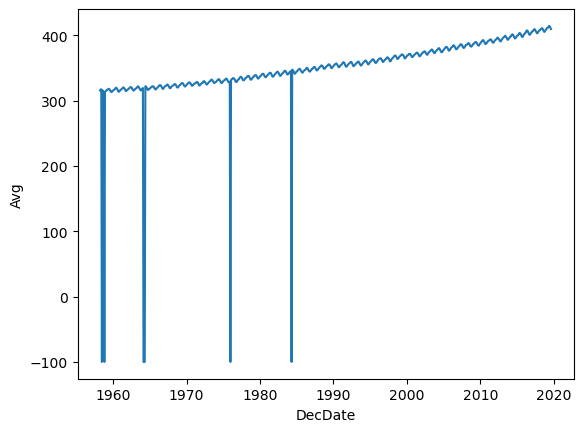

In [50]:
sns.lineplot(x='DecDate', y='Avg', data=co2);

- The sudden drops indicate `0` or `NaN`, i.e. missing values

In [51]:
display(co2.head())
display(co2.tail())

,Yr,Mo,DecDate,Avg,Int,Trend,Days
0,1958,3,1958.208,315.71,315.71,314.62,-1
1,1958,4,1958.292,317.45,317.45,315.29,-1
2,1958,5,1958.375,317.50,317.50,314.71,-1
3,1958,6,1958.458,-99.99,317.10,314.85,-1
4,1958,7,1958.542,315.86,315.86,314.98,-1


,Yr,Mo,DecDate,Avg,Int,Trend,Days
733,2019,4,2019.292,413.32,413.32,410.49,26
734,2019,5,2019.375,414.66,414.66,411.20,28
735,2019,6,2019.458,413.92,413.92,411.58,27
736,2019,7,2019.542,411.77,411.77,411.43,23
737,2019,8,2019.625,409.95,409.95,411.84,29


- Some data have unusual values like -1 and -99.99

- -1 signifies a missing value for the number of days `Days` the equipment was in operation that month

- -99.99 denotes a missing monthly average `Avg`

### Understanding Missing Value 1: Days

In [ ]:
# Check months in the dataset, and see if there are any missing months
co2["Mo"].value_counts().sort_index()

Mo
1     61
2     61
3     62
4     62
5     62
6     62
7     62
8     62
9     61
10    61
11    61
12    61
Name: count, dtype: int64

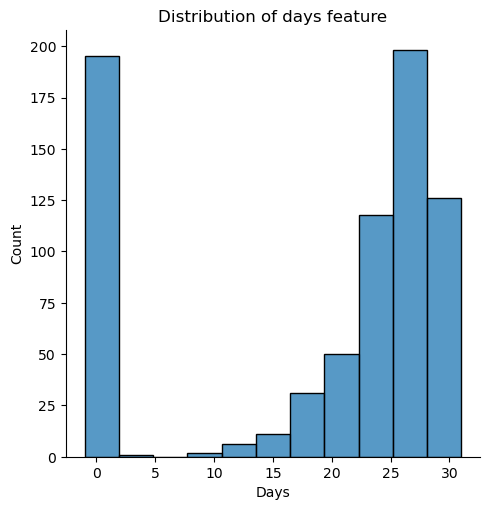

In [ ]:
# Check the days
sns.displot(co2['Days']);
plt.title("Distribution of days feature"); # suppresses unneeded plotting output

- The bar around 0 indicates there are nearly 200 missing values

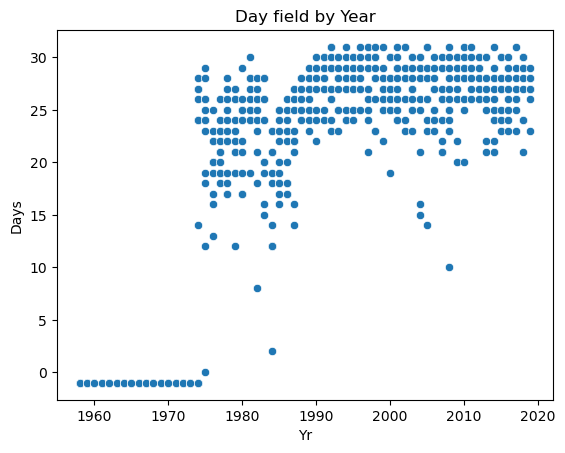

In [54]:
# check the years
sns.scatterplot(x="Yr", y="Days", data=co2);
plt.title("Day field by Year"); # the ; suppresses output

- Missing values are common in the early years before around 1975

### Understanding Missing Value 2: `Avg`

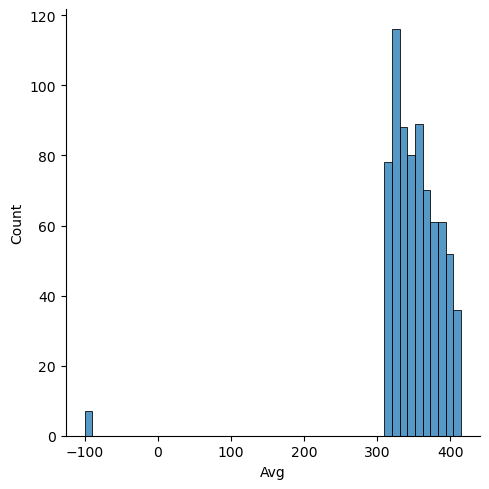

In [55]:
# Histograms of average CO2 measurements
sns.displot(co2['Avg']);

- Quite few missing values below 0

In [56]:
co2[co2["Avg"] < 0]

,Yr,Mo,DecDate,Avg,Int,Trend,Days
3,1958,6,1958.458,-99.99,317.10,314.85,-1
7,1958,10,1958.792,-99.99,312.66,315.61,-1
71,1964,2,1964.125,-99.99,320.07,319.61,-1
72,1964,3,1964.208,-99.99,320.73,319.55,-1
73,1964,4,1964.292,-99.99,321.77,319.48,-1
213,1975,12,1975.958,-99.99,330.59,331.60,0
313,1984,4,1984.292,-99.99,346.84,344.27,2


### Drop, `NaN`, or Impute Missing Avg Data?

- Recall the figure we are trying to fix

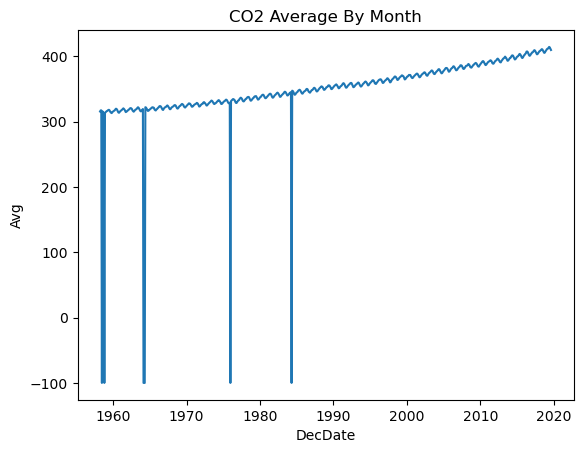

In [57]:
sns.lineplot(x='DecDate', y='Avg', data=co2)
plt.title("CO2 Average By Month");

In [58]:
# 1. Drop missing values
co2_drop = co2[co2['Avg'] > 0]
co2_drop.head()

,Yr,Mo,DecDate,Avg,Int,Trend,Days
0,1958,3,1958.208,315.71,315.71,314.62,-1
1,1958,4,1958.292,317.45,317.45,315.29,-1
2,1958,5,1958.375,317.50,317.50,314.71,-1
4,1958,7,1958.542,315.86,315.86,314.98,-1
5,1958,8,1958.625,314.93,314.93,315.94,-1


In [61]:
# 2. Replace NaN with -99.99
co2_NA = co2.replace(-99.99, np.nan)
co2_NA.head()

,Yr,Mo,DecDate,Avg,Int,Trend,Days
0,1958,3,1958.208,315.71,315.71,314.62,-1
1,1958,4,1958.292,317.45,317.45,315.29,-1
2,1958,5,1958.375,317.50,317.50,314.71,-1
3,1958,6,1958.458,NaN,317.10,314.85,-1
4,1958,7,1958.542,315.86,315.86,314.98,-1


- From the file description:

*The interpolated column includes average values from the preceding column (average) and interpolated values where data are missing. Interpolated values are computed in two steps...*

The Int feature has values that exactly match those in Avg, except when Avg is -99.99, and then a reasonable estimate is used instead

In [62]:
# 3. Use interpolated column which estimates missing Avg values
co2_impute = co2.copy()
co2_impute['Avg'] = co2['Int']
co2_impute.head()

,Yr,Mo,DecDate,Avg,Int,Trend,Days
0,1958,3,1958.208,315.71,315.71,314.62,-1
1,1958,4,1958.292,317.45,317.45,315.29,-1
2,1958,5,1958.375,317.50,317.50,314.71,-1
3,1958,6,1958.458,317.10,317.10,314.85,-1
4,1958,7,1958.542,315.86,315.86,314.98,-1


- Let's compare which is more reasonable

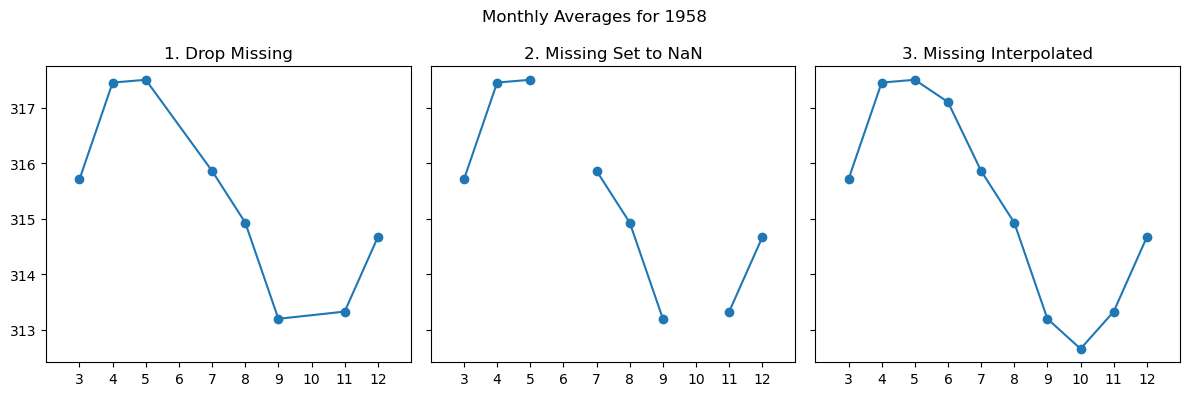

In [63]:
# results of plotting data in 1958

def line_and_points(data, ax, title):
    # axssumes single year, hence Mo
    ax.plot('Mo', 'Avg', data=data)
    ax.scatter('Mo', 'Avg', data=data)
    ax.set_xlim(2, 13)
    ax.set_title(title)
    ax.set_xticks(np.arange(3, 13))

def data_year(data, year):
    return data[data["Yr"] == 1958]
    
# uses matplotlib subplots
# you may see more next week; focus on output for now
fig, axes = plt.subplots(ncols = 3, figsize=(12, 4), sharey=True)

year = 1958
line_and_points(data_year(co2_drop, year), axes[0], title="1. Drop Missing")
line_and_points(data_year(co2_NA, year), axes[1], title="2. Missing Set to NaN")
line_and_points(data_year(co2_impute, year), axes[2], title="3. Missing Interpolated")

fig.suptitle(f"Monthly Averages for {year}")
plt.tight_layout()

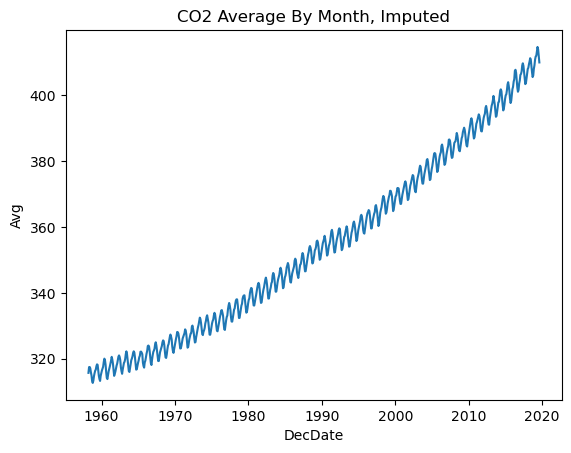

In [ ]:
# Replot our original figure with option 3
sns.lineplot(x='DecDate', y='Avg', data=co2_impute)
plt.title("CO2 Average By Month, Imputed");

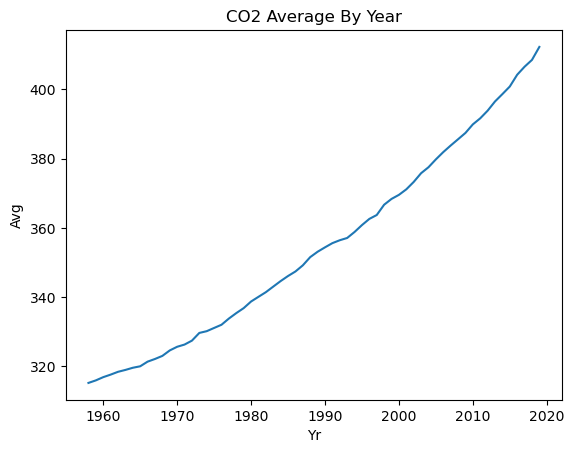

In [65]:
co2_year = co2_impute.groupby('Yr').mean()
sns.lineplot(x='Yr', y='Avg', data=co2_year)
plt.title("CO2 Average By Year");

---
[Reference](https://ds100.org/course-notes/eda/)